# JSE Sector Momentum Strategy - Research Notebook
## Stage 3: Exploratory Data Analysis

### Objective
Transform the price data into returns for analysis and then analyse 
the data to learn more about each sector and how it performed in 
each period.

### Input File
The analysis was done using the clean daily prices file here: 
data/jse_sector_prices_clean_2019_2026.csv

### Steps
1. Transform data into log monthly returns
2. Compute overall performance for each sector over the whole period
3. Compute the standard deviation and average monthly return for each sector
4. Use a histogram to view return distributions
5. Create a correlation matrix
6. Plot cumulative returns for all sectors

### Key Findings
- Resources had the highest return at 16.2% annually but also the highest volatility at 29.3%
- Consumer Goods had the best risk-adjusted return with low volatility and stable cumulative growth
- Industrials had a negative annual return of -3.5% and never fully recovered from COVID
- Financials and Industrials are highly correlated at 77%
- Resources has the lowest correlation with all other sectors driven by global commodity prices rather than SA domestic factors
- Cumulative returns confirm divergence between sectors, supporting the case for a rotation strategy

### Output
A cleaned monthly log returns dataframe ready for signal construction 
in Stage 4.

### Next Step
Stage 4 — Signal Construction: Build a momentum signal using 12-1 month momentum scores for each sector and rank sectors by signal strength each month.

## Step 1: Load Indicies Data

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Data
df = pd.read_csv('data/jse_sector_prices_clean_2019_2026.csv', index_col= "Date", parse_dates = True)
# View the the shape and first 5 rows
print(df.shape)
print(df.head())





(1817, 4)
              Financials     Resources   Industrials  Consumer Goods
Date                                                                
2019-01-02  40406.269531  27932.660156  43395.171875    49021.589844
2019-01-03  40985.550781  28209.990234  43877.710938    48981.871094
2019-01-04  41332.500000  28280.140625  44619.699219    49273.308594
2019-01-07  41206.691406  28302.970703  44599.800781    48565.679688
2019-01-08  41161.808594  28446.019531  44689.531250    49551.781250


## Step 2: Convert Daily prices to monthly log returns 
We resample daily closing prices top month-end and compute log returns. log returns are used because they are time additive and handle compunding correctly accross periods.

In [13]:
# Resample the data to only frequency and calculate final value for each month
month_end_df = df.resample('ME').last()
month_end_df.tail()
print(month_end_df.shape)

(88, 4)


In [14]:
# Compute Log returns
log_returns_df = np.log(month_end_df/ month_end_df.shift(1)).dropna()
print(log_returns_df.head())

            Financials  Resources  Industrials  Consumer Goods
Date                                                          
2019-02-28   -0.021239   0.087303    -0.024094        0.118959
2019-03-31   -0.046531   0.030868    -0.058845        0.014972
2019-04-30    0.044953  -0.023175     0.057251       -0.006261
2019-05-31   -0.025558  -0.052975    -0.039682       -0.021071
2019-06-30    0.011440   0.096746    -0.044402        0.076821


In [15]:
# Save monthly log returns for use in Stage 4
log_returns_df.to_csv("data/jse_sector_monthly_log_returns_2019_2026.csv")
print("Saved monthly log returns")
print(log_returns_df)

Saved monthly log returns
            Financials  Resources  Industrials  Consumer Goods
Date                                                          
2019-02-28   -0.021239   0.087303    -0.024094        0.118959
2019-03-31   -0.046531   0.030868    -0.058845        0.014972
2019-04-30    0.044953  -0.023175     0.057251       -0.006261
2019-05-31   -0.025558  -0.052975    -0.039682       -0.021071
2019-06-30    0.011440   0.096746    -0.044402        0.076821
...                ...        ...          ...             ...
2025-12-31    0.061017   0.055691     0.042958       -0.010925
2026-01-31    0.026575   0.119353    -0.008396       -0.000289
2026-02-28    0.069043   0.125926     0.062416        0.018754
2026-03-31   -0.110341  -0.187604    -0.078638       -0.031724
2026-04-30    0.032798   0.052240     0.025755       -0.003299

[87 rows x 4 columns]


## Step 3: Summary Statistics 

Compute the mothly return, standard deviation and annualisedf return figures for each sector. This tells us which sectors have historicallyu delivered the best risk adjusted return


In [16]:
# Calculate mean monthly returns for each asset

mean_monthly_returns = log_returns_df.mean()
print(f'Mean Monthly Returns:\n{mean_monthly_returns}')

# Calculate the standard deiviation (volatility) for each asset)
monthly_std = log_returns_df.std()
print(f'Standard Deiviation (Volatility:\n{monthly_std}')

summary = pd.DataFrame({
    'Annual Return': mean_monthly_returns * 12,
    'Annual Volatility': monthly_std * np.sqrt(12)
})
print(summary)

Mean Monthly Returns:
Financials        0.004052
Resources         0.013505
Industrials      -0.002926
Consumer Goods    0.007530
dtype: float64
Standard Deiviation (Volatility:
Financials        0.066442
Resources         0.084636
Industrials       0.054778
Consumer Goods    0.043641
dtype: float64
                Annual Return  Annual Volatility
Financials           0.048628           0.230162
Resources            0.162062           0.293188
Industrials         -0.035116           0.189757
Consumer Goods       0.090355           0.151178


In [17]:
# Identify the highest yielding, worst yielding, riskiest, and highest risk-adjusted return sectors

highest_yielding_sector = summary['Annual Return'].idxmax()
worst_yielding_sector = summary['Annual Return'].idxmin()
riskiest_sector = summary['Annual Volatility'].idxmax()
highest_risk_adjusted_return_sector = (summary['Annual Return'] / summary['Annual Volatility']).idxmax()

print(f'Highest Yielding Sector: {highest_yielding_sector} : {summary.loc[highest_yielding_sector, "Annual Return"]:.2%}')
print(f'Worst Yielding Sector: {worst_yielding_sector} : {summary.loc[worst_yielding_sector, "Annual Return"]:.2%}')
print(f'Riskiest Sector: {riskiest_sector} : {summary.loc[riskiest_sector, "Annual Volatility"]:.2%}')
print(f'Highest Risk-Adjusted Return Sector: {highest_risk_adjusted_return_sector} : {summary.loc[highest_risk_adjusted_return_sector, "Annual Return"] / summary.loc[highest_risk_adjusted_return_sector, "Annual Volatility"]:.2%}')






Highest Yielding Sector: Resources : 16.21%
Worst Yielding Sector: Industrials : -3.51%
Riskiest Sector: Resources : 29.32%
Highest Risk-Adjusted Return Sector: Consumer Goods : 59.77%


### Interpretation — Summary Statistics

Resources delivered the highest annualised return at 16.2% but carried the highest volatility at 29.3%, reflecting exposure to global commodity prices and ZAR currency risk.

Industrials was the only sector with a negative return at -3.5%, consistent with the structural decline in SA manufacturing and refining capacity over this period.

Consumer Goods delivered the best risk-adjusted return — 9.0% return against 15.1% volatility — reflecting resilient aggregate demand in 
South Africa despite macroeconomic headwinds.

Financials delivered moderate returns of 4.9% with mid-range volatility, reflecting the interest rate cycle and banking sector pressures through this period.

## Step 4: Return Distribution Analysis

Visualise the distribution of the log monthly returns for the sectors. This will tell us if the returns are normally distributes or whether they vave fat tails that is extreeme move that happen more than a normal distributions would predict.

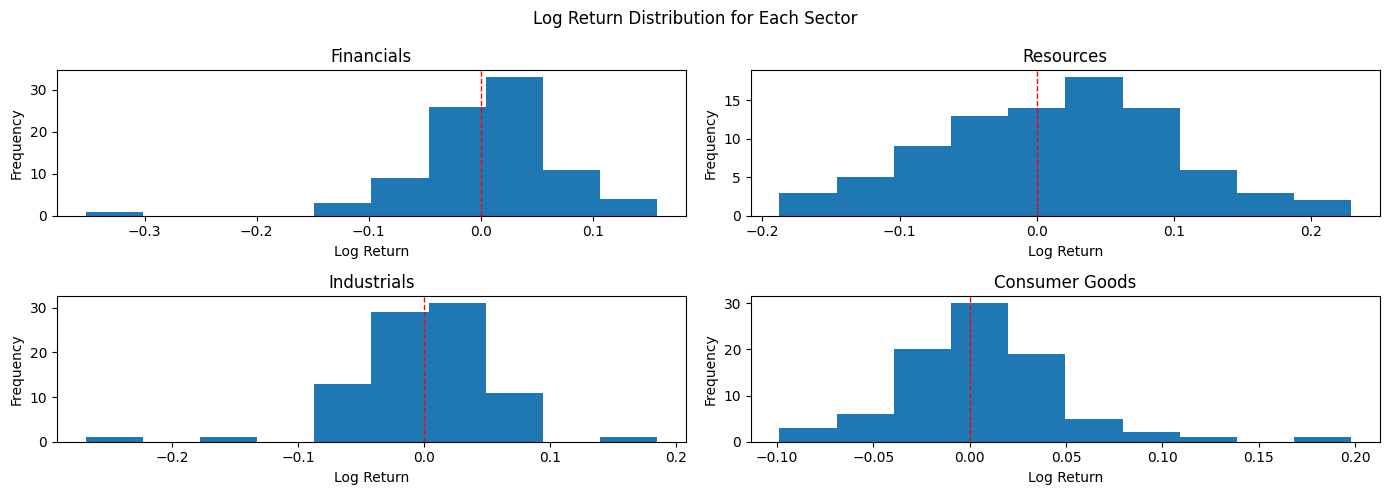

In [18]:
#Plot the distribution for each sector
fig, axes = plt.subplots(2,2,figsize=(14,5))
axes = axes.flatten()
for i, col in enumerate(log_returns_df.columns):
    axes[i].hist(log_returns_df[col], bins=10, linewidth = 0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel("Frequency")
    axes[i].set_xlabel("Log Return")
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=1)

plt.suptitle("Log Return Distribution for Each Sector")
plt.tight_layout()
plt.show()

### Distribution Interpretation

The Financials distribution is slightly concentrated around zero but has a pronounced left tail, with a few extreme negative returns 
exceeding -30%. The downside risk is asymmetric — most months are unremarkable but occasional severe crashes are a feature of this sector.

The Resources distribution is flat with fat tails on both sides. The bulk of the distribution is positive so positive returns are more frequent, but the flatness shows that month-to-month returns are highly unpredictable. The tails are wide but consistent, falling within a range of approximately ±20%, which demonstrates that the risk in Resources is high but priceable.

Industrials have the bulk of returns concentrated within ±10%, so most months are uneventful. However there are extreme values on both sides — the negative extremes likely reflecting the COVID crash and structural sector decline, the positive extreme reflecting the post-COVID recovery bounce.

Consumer Goods has the closest to a normally distributed return profile, though it is slightly skewed to the right with some extreme positive returns near 20%, while negative returns remain below 10%. This shape is consistent with the earlier finding that Consumer Goods has the best overall risk-adjusted return of the four sectors.

## Step 5: Correlation Matrix

Measures how closely sector returns move together. A correlation of 1 means two sectors move in perfect lockstep. A correlation of -1 means they move in opposite directions. A correlation near 0 means they move 
ndependently.

For a rotation strategy, low correlation between sectors is desirable — it means sectors take turns leading, which is exactly the condition that makes rotation worthwhile.


In [19]:
# Calculate the correlation matrix for the log returns
corr_matrix = log_returns_df.corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                Financials  Resources  Industrials  Consumer Goods
Financials        1.000000   0.370649     0.774882        0.568647
Resources         0.370649   1.000000     0.351218        0.298799
Industrials       0.774882   0.351218     1.000000        0.544216
Consumer Goods    0.568647   0.298799     0.544216        1.000000


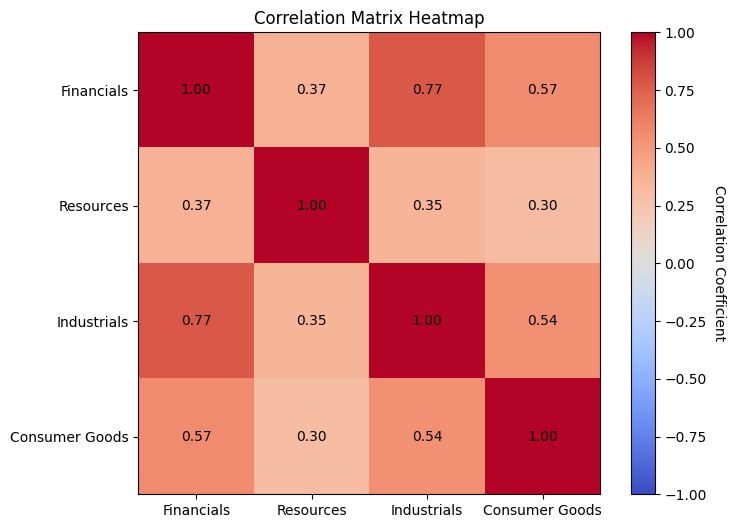

In [20]:
# Plot the correlation matrix as a heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlation Coefficient", rotation=-90, va="bottom")

# Set axis lable
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.index)

# Optional: Add the actual correlation numbers inside the cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", 
                ha="center", va="center", color="black")

plt.title("Correlation Matrix Heatmap")
plt.show()


### Correlation Matrix Interpretation

Resources generally have a lower correlation with all other sectors, ranging from 30% to 37%, with its correlation with Consumer Goods being the lowest at 30%. This is likely because the Resources sector is essentially driven by global commodity prices, which are separate from the internal economic performance of South Africa.

Industrials and Financials have the highest correlation of 77%, which is expected because industry is the biggest customer of the finance industry and the opposite is also true.

Overall the correlations range from 30% to 77%, which means there is scope for rotation, with the pairs below 50% presenting a bigger opportunity and the 50% to 80% range offering a moderate opportunity.

## Step 6: Cumulative Returns

Visualise how each sector has grown over the full period relative to a starting value of 1. This shows which sectors led and lagged at different points in time — the foundation for understanding momentum patterns.

            Financials  Resources  Industrials  Consumer Goods
Date                                                          
2019-02-28    0.978985   1.091228     0.976194        1.126324
2019-03-31    0.934475   1.125437     0.920408        1.143314
2019-04-30    0.977441   1.099656     0.974639        1.136179
2019-05-31    0.952776   1.042918     0.936721        1.112489
2019-06-30    0.963738   1.148858     0.896038        1.201320
...                ...        ...          ...             ...
2025-12-31    1.397217   2.900934     0.774353        1.957427
2026-01-31    1.434845   3.268679     0.767878        1.956862
2026-02-28    1.537411   3.707331     0.817334        1.993907
2026-03-31    1.376796   3.073164     0.755522        1.931645
2026-04-30    1.422700   3.237975     0.775234        1.925284

[87 rows x 4 columns]


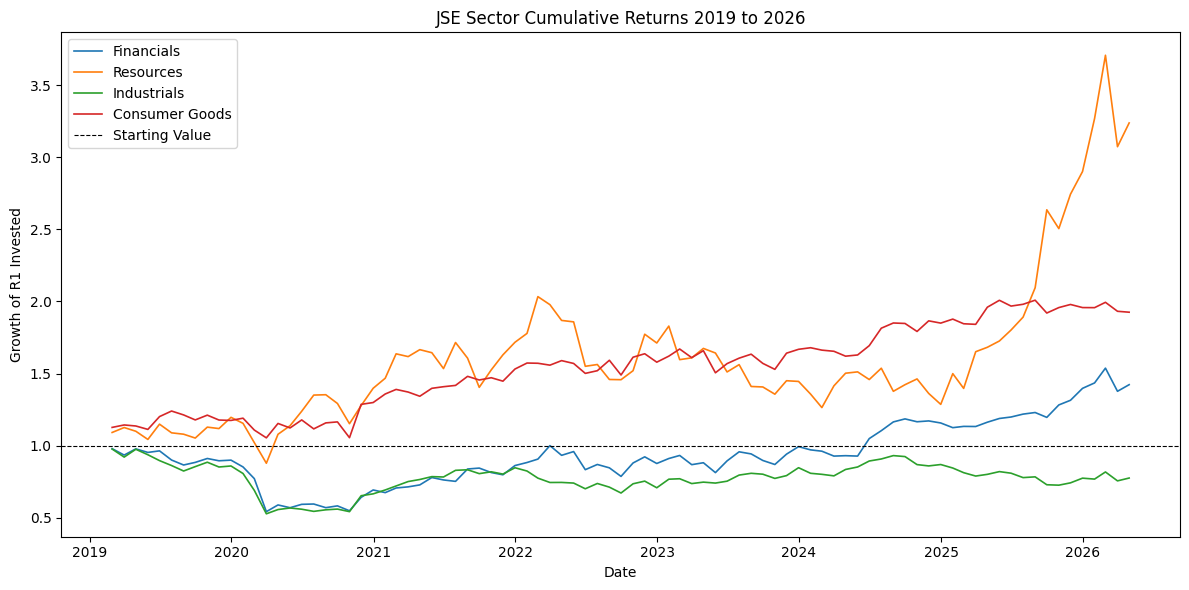

In [21]:
# Calculate cumulative returns for each sector
cumulative_returns = np.exp(log_returns_df.cumsum())
print(cumulative_returns)

# Plot all sectors on one chart
fig, ax = plt.subplots(figsize=(12, 6))

for col in cumulative_returns.columns:
    ax.plot(cumulative_returns.index, cumulative_returns[col], linewidth=1.2, label=col)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, label='Starting Value')
ax.set_title("JSE Sector Cumulative Returns 2019 to 2026")
ax.set_ylabel("Growth of R1 Invested")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()